# LSTM Model (Deep Learning Model)

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 471,494 (1.80 MB)

 Trainable params: 471,110 (1.80 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.5674 - loss: 0.8450 - val_accuracy: 0.6281 - val_loss: 0.6655
Epoch 2/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.6705 - loss: 0.5608 - val_accuracy: 0.6893 - val_loss: 0.6057
Epoch 3/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.6975 - loss: 0.5213 - val_accuracy: 0.6526 - val_loss: 0.6712
Epoch 4/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.7291 - loss: 0.4819 - val_accuracy: 0.7070 - val_loss: 0.6142
Epoch 5/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.7670 - loss: 0.4319 - val_accuracy: 0.7328 - val_loss: 0.5926
Epoch 6/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.7873 - loss: 0.4263 - val_accuracy: 0.6587 - val_loss: 0.8391
Epoch 7/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.7956 - loss: 0.3885 - val_accuracy: 0.7539 - val_loss: 0.6775
Epoch 8/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.8104 - loss: 0.3561 - val_accuracy: 0

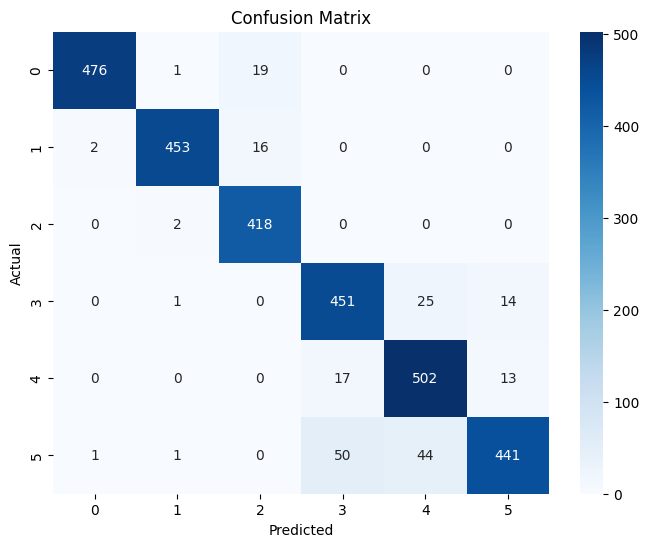

In [1]:
# ==============================
# 1. IMPORTS
# ==============================
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==============================
# 2. LOAD DATA
# ==============================
def load_signal(file):
    return pd.read_csv(file, sep='\s+', header=None).values

base = r"C:\Users\HP\Downloads\UCI-HAR Dataset"

def load_dataset(split):
    X = np.array([
        load_signal(f"{base}\\{split}\\Inertial Signals\\body_acc_x_{split}.txt"),
        load_signal(f"{base}\\{split}\\Inertial Signals\\body_acc_y_{split}.txt"),
        load_signal(f"{base}\\{split}\\Inertial Signals\\body_acc_z_{split}.txt"),
        load_signal(f"{base}\\{split}\\Inertial Signals\\body_gyro_x_{split}.txt"),
        load_signal(f"{base}\\{split}\\Inertial Signals\\body_gyro_y_{split}.txt"),
        load_signal(f"{base}\\{split}\\Inertial Signals\\body_gyro_z_{split}.txt")
    ]).transpose(1,2,0)

    y = pd.read_csv(f"{base}\\{split}\\y_{split}.txt", header=None).values.ravel() - 1
    return X, y

X_train, y_train = load_dataset("train")
X_test, y_test = load_dataset("test")

# ==============================
# 3. NORMALIZATION
# ==============================
mean = X_train.mean(axis=(0,1), keepdims=True)
std = X_train.std(axis=(0,1), keepdims=True)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# ==============================
# 4. MODEL (CNN + BiLSTM 🔥)
# ==============================
model = tf.keras.Sequential([
    
    # CNN feature extractor
    tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same', input_shape=(128,6)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),

    # LSTM part
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),

    # Dense
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ==============================
# 5. CLASS WEIGHTS
# ==============================
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(enumerate(weights))

# ==============================
# 6. CALLBACKS
# ==============================


# ==============================
# 7. TRAIN
# ==============================
history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

# ==============================
# 8. EVALUATION
# ==============================
loss, acc = model.evaluate(X_test, y_test)
print("\n✅ Test Accuracy:", acc)

y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==============================
# 9. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ==============================
# 10. SAVE MODEL
# ==============================
os.makedirs("models", exist_ok=True)
model.save("models/LSTM_model.keras")

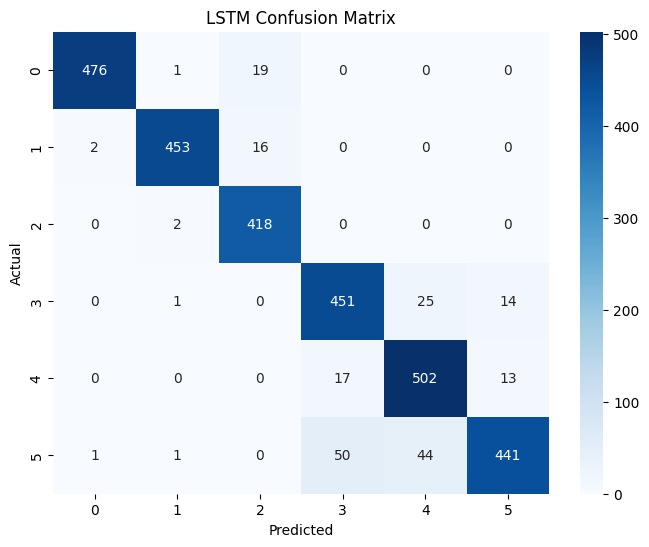

In [2]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")
plt.show()